In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
file_path = 'winequality-white.csv'
data1 = pd.read_csv(file_path)

In [27]:
print(f"Number of duplicate rows: {data1.duplicated().sum()}")
data = data1

Number of duplicate rows: 937


In [29]:
missing_values = data.isnull().sum()

# Display missing values
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [30]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


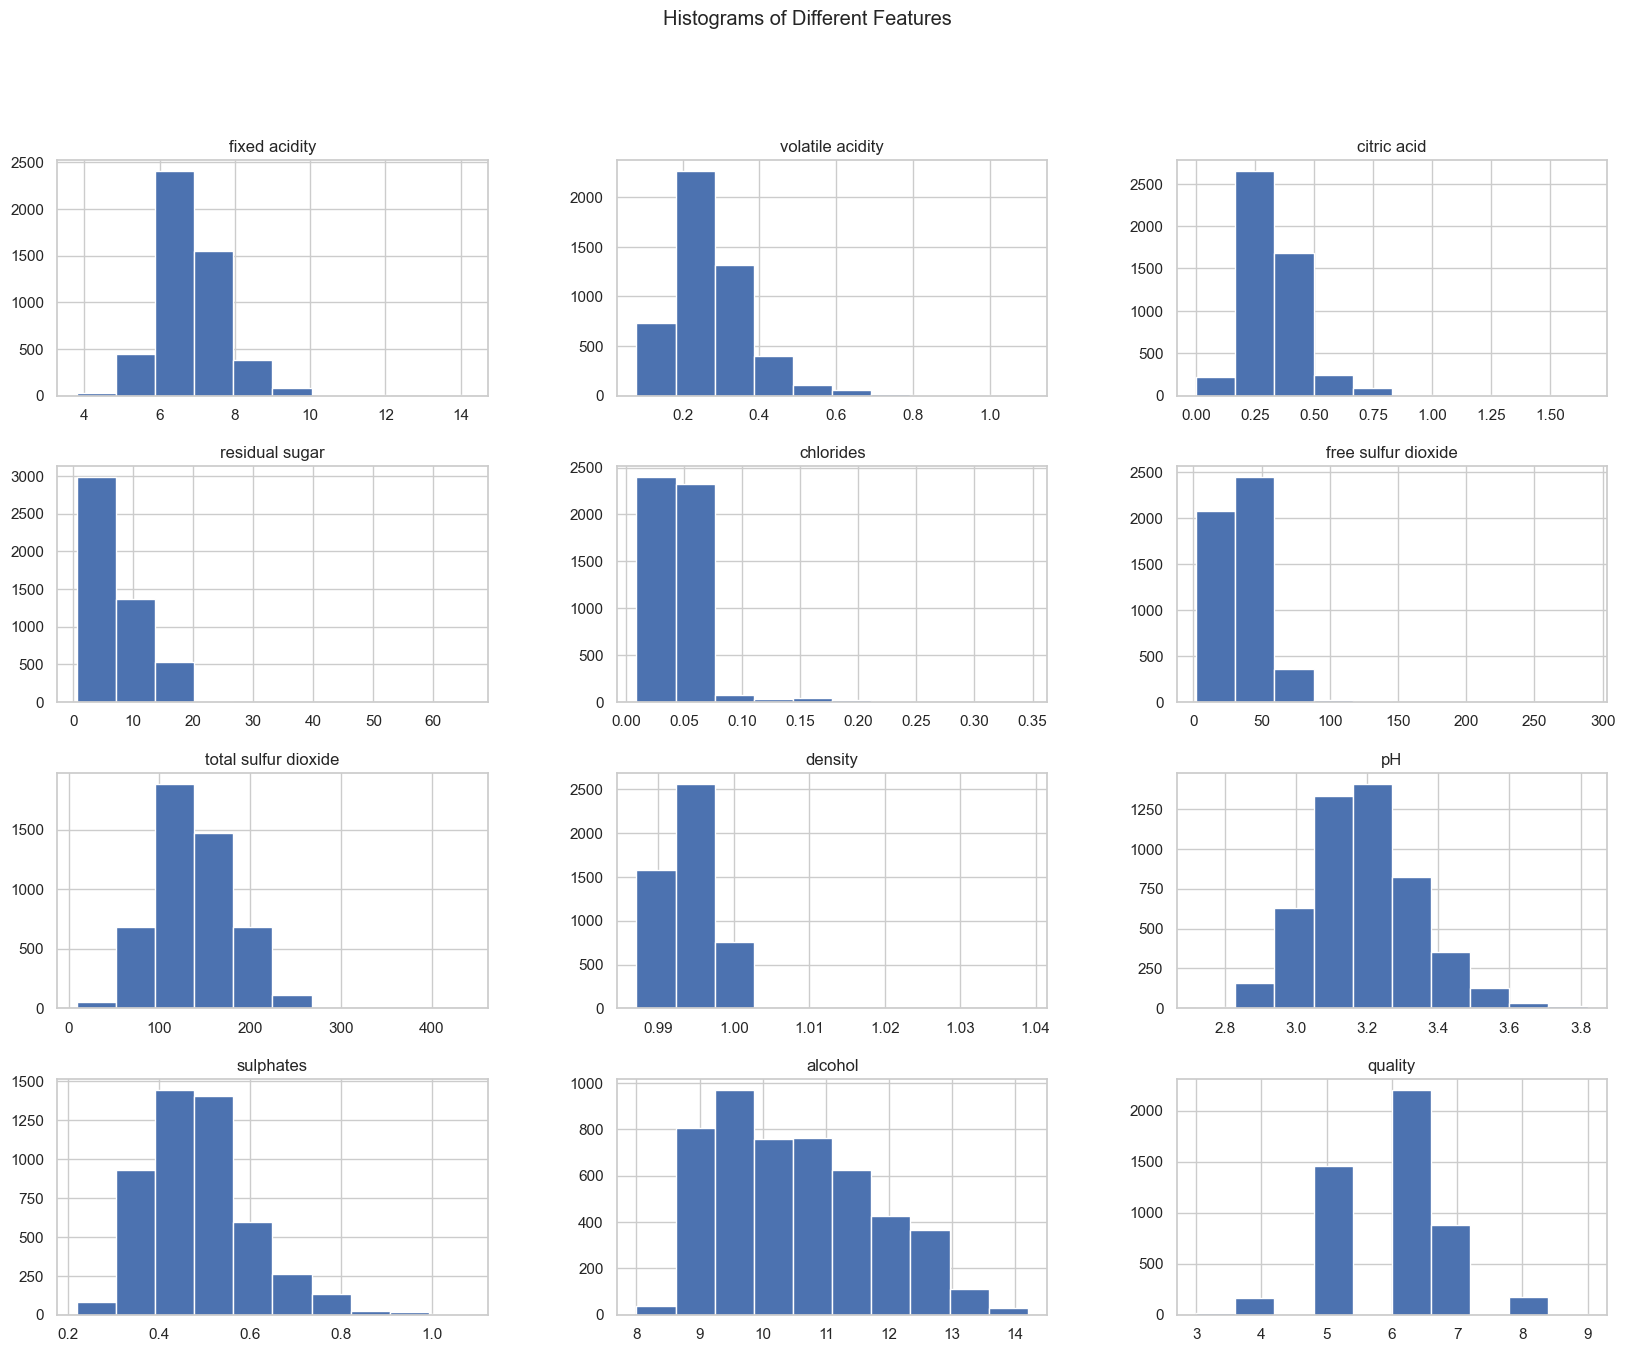

In [31]:
sns.set(style="whitegrid")

# Histograms for each feature
data.hist(bins=10, figsize=(20, 15))
plt.suptitle('Histograms of Different Features')
plt.show()

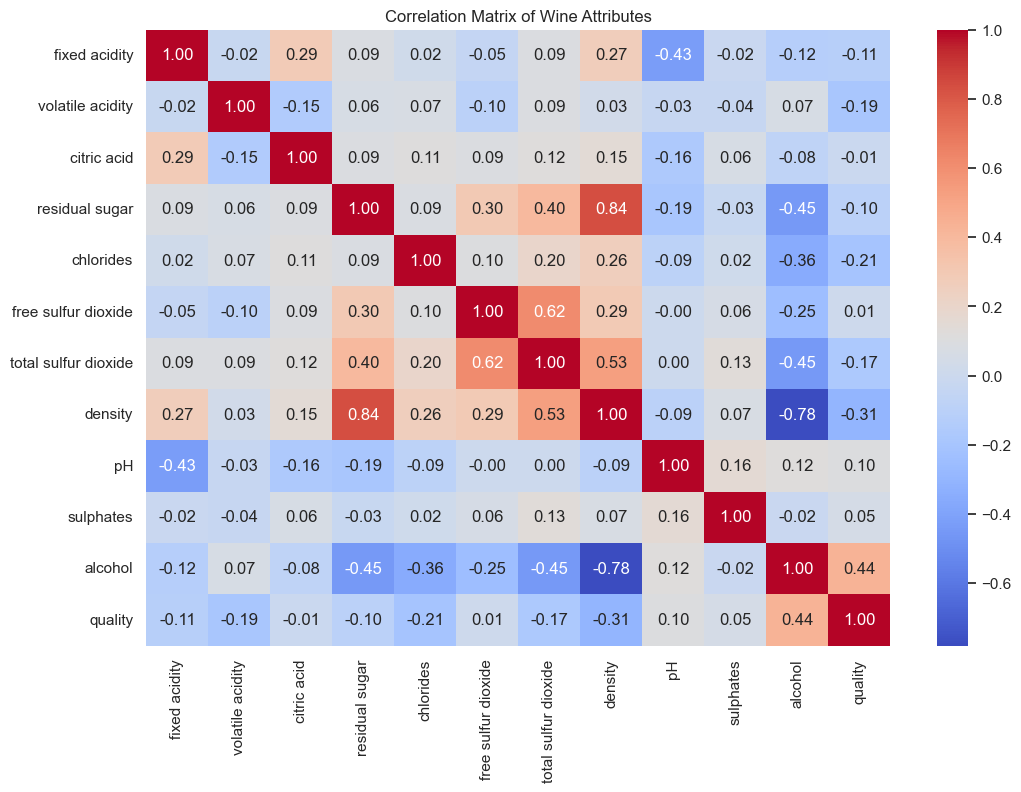

In [54]:
correlation_matrix = data.corr()
correlation_matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Wine Attributes')
plt.show()

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X = data.drop('quality', axis=1)
y = data['quality']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')
print(f"Logistic Regression: Accuracy = {accuracy_lr:.4f}, F1 Score = {f1_lr:.4f}")


Logistic Regression: Accuracy = 0.5316, F1 Score = 0.4978


In [34]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')
print(f"KNN: Accuracy = {accuracy_knn:.4f}, F1 Score = {f1_knn:.4f}")


KNN: Accuracy = 0.5490, F1 Score = 0.5420


In [35]:
from sklearn.svm import SVC

# SVM Linear
svm_linear_model = SVC(kernel="linear", random_state=42)
svm_linear_model.fit(X_train, y_train)
y_pred_svm_linear = svm_linear_model.predict(X_test)

accuracy_svm_linear = accuracy_score(y_test, y_pred_svm_linear)
f1_svm_linear = f1_score(y_test, y_pred_svm_linear, average='weighted')
print(f"SVM Linear: Accuracy = {accuracy_svm_linear:.4f}, F1 Score = {f1_svm_linear:.4f}")


SVM Linear: Accuracy = 0.5092, F1 Score = 0.4294


In [36]:
# SVM Polynomial
svm_poly_model = SVC(kernel="poly", random_state=42)
svm_poly_model.fit(X_train, y_train)
y_pred_svm_poly = svm_poly_model.predict(X_test)

accuracy_svm_poly = accuracy_score(y_test, y_pred_svm_poly)
f1_svm_poly = f1_score(y_test, y_pred_svm_poly, average='weighted')
print(f"SVM Poly: Accuracy = {accuracy_svm_poly:.4f}, F1 Score = {f1_svm_poly:.4f}")


SVM Poly: Accuracy = 0.5235, F1 Score = 0.4682


In [37]:
# SVM RBF
svm_rbf_model = SVC(kernel="rbf", random_state=42)
svm_rbf_model.fit(X_train, y_train)
y_pred_svm_rbf = svm_rbf_model.predict(X_test)

accuracy_svm_rbf = accuracy_score(y_test, y_pred_svm_rbf)
f1_svm_rbf = f1_score(y_test, y_pred_svm_rbf, average='weighted')
print(f"SVM RBF: Accuracy = {accuracy_svm_rbf:.4f}, F1 Score = {f1_svm_rbf:.4f}")


SVM RBF: Accuracy = 0.5602, F1 Score = 0.5260


In [38]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
print(f"Random Forest: Accuracy = {accuracy_rf:.4f}, F1 Score = {f1_rf:.4f}")


Random Forest: Accuracy = 0.6898, F1 Score = 0.6821


In [39]:
from sklearn.ensemble import ExtraTreesClassifier

# Extra Trees
et_model = ExtraTreesClassifier(random_state=42)
et_model.fit(X_train, y_train)
y_pred_et = et_model.predict(X_test)

accuracy_et = accuracy_score(y_test, y_pred_et)
f1_et = f1_score(y_test, y_pred_et, average='weighted')
print(f"Extra Trees: Accuracy = {accuracy_et:.4f}, F1 Score = {f1_et:.4f}")


Extra Trees: Accuracy = 0.6990, F1 Score = 0.6931


In [40]:
from sklearn.ensemble import BaggingClassifier

# Bagging
bagging_model = BaggingClassifier(random_state=42)
bagging_model.fit(X_train, y_train)
y_pred_bagging = bagging_model.predict(X_test)

accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
f1_bagging = f1_score(y_test, y_pred_bagging, average='weighted')
print(f"Bagging: Accuracy = {accuracy_bagging:.4f}, F1 Score = {f1_bagging:.4f}")


Bagging: Accuracy = 0.6663, F1 Score = 0.6615


In [41]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')
print(f"Decision Tree: Accuracy = {accuracy_dt:.4f}, F1 Score = {f1_dt:.4f}")

Decision Tree: Accuracy = 0.6071, F1 Score = 0.6098


In [42]:
models = pd.DataFrame({
    'Model' : ['Logistic Regression', 'KNN', 'SVM_linear',  'SVM_Poly', 'SVM_RBF','Random Forest', 'Extra Trees','Bagging','Decision Tree'],
    'Accuracy' : [accuracy_lr, accuracy_knn, accuracy_svm_linear, accuracy_svm_poly, accuracy_svm_rbf, accuracy_rf, accuracy_et, accuracy_bagging,accuracy_dt],
    'F1 Score' : [f1_lr,f1_knn,f1_svm_linear,f1_svm_poly,f1_svm_rbf,f1_rf,f1_et,f1_bagging,f1_dt]
})

models.sort_values(by = 'Accuracy', ascending = True)

,Model,Accuracy,F1 Score
2,SVM_linear,0.509184,0.429373
3,SVM_Poly,0.523469,0.468241
0,Logistic Regression,0.531633,0.497822
1,KNN,0.548980,0.541983
4,SVM_RBF,0.560204,0.525990
8,Decision Tree,0.607143,0.609771
7,Bagging,0.666327,0.661469
5,Random Forest,0.689796,0.682056
6,Extra Trees,0.698980,0.693115


## Feature selection
Method Selection: The effectiveness of feature selection largely depends on the methods used (filter, wrapper, embedded) and their alignment with the model type and data characteristics. Each method has its advantages and is suited to different scenarios.

Balance Between Performance and Complexity: There's a trade-off between simplifying the model and maintaining enough features to capture the underlying data complexity. Removing too many features can lead to underfitting, where the model fails to capture important patterns.

Validation is Key: It’s crucial to validate the feature selection process and its impact on model performance through cross-validation or similar techniques to ensure that the selected features genuinely contribute to model improvement.

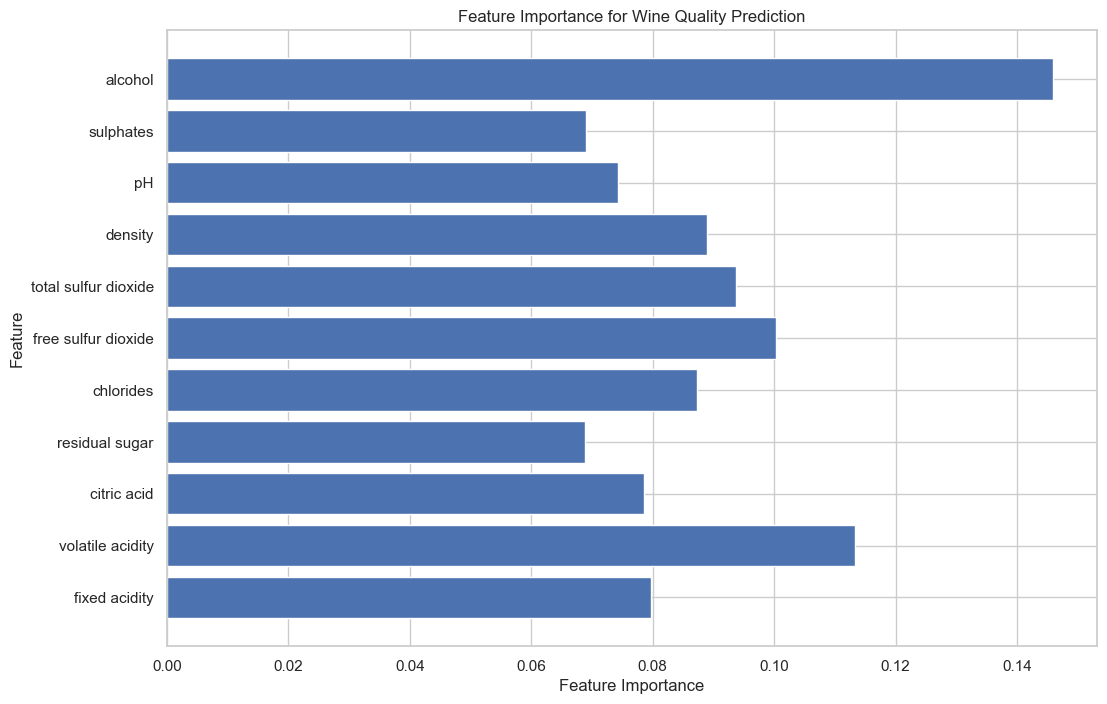

In [52]:
import numpy as np

# Feature Selection based on decion tree feature importances
feature_importances = dt_model.feature_importances_
important_features = X.columns[feature_importances > np.mean(feature_importances)]

plt.figure(figsize=(12, 8))
plt.barh(X.columns, feature_importances)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for Wine Quality Prediction')
plt.show()

# Stacking Model
Performance Improvement: The stacking model can potentially outperform any single base classifier by leveraging their strengths and mitigating their weaknesses. The improvement depends on how complementary the base classifiers are and the complexity of the data.

Complexity and Interpretability: While stacking can improve performance, it also increases the model's complexity and reduces interpretability. Each additional layer of models adds complexity to the training process and makes it harder to diagnose and understand predictions.

Risk of Overfitting: There's an increased risk of overfitting, especially if the meta-classifier is too complex or if there's not enough diversity among base classifiers. Careful tuning and validation are essential.

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Assuming X and y are defined as per the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define base classifiers
base_classifiers = [
    ('rf', RandomForestClassifier(n_estimators=10, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('svc', SVC(random_state=42))
]

# Define the stacking ensemble model
stacking_model = StackingClassifier(
    estimators=base_classifiers, 
    final_estimator=LogisticRegression(),
    cv=5
)

# Fit the stacking model
stacking_model.fit(X_train, y_train)

# Make predictions and evaluate the model
y_pred = stacking_model.predict(X_test)
print(classification_report(y_test, y_pred))


C:\Users\HON\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           3       0.00      0.00      0.00         5
           4       0.56      0.20      0.29        25
           5       0.68      0.60      0.64       291
           6       0.63      0.78      0.70       432
           7       0.71      0.59      0.64       192
           8       0.68      0.43      0.53        35

    accuracy                           0.66       980
   macro avg       0.54      0.43      0.47       980
weighted avg       0.66      0.66      0.65       980



C:\Users\HON\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\HON\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\HON\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1471: Unde

# Eliminate samples of classes with little data

In [56]:
df = pd.read_csv('winequality-white.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [57]:
quality_counts = df['quality'].value_counts().sort_index()
quality_counts

quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: count, dtype: int64

In [58]:
df = df[~df['quality'].isin([3, 4, 8,9])]
df.reset_index(drop=True, inplace=True)
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4530,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4531,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4532,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4533,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [70]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X = df.drop('quality', axis=1)
y = df['quality']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [71]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
print(f"Random Forest: Accuracy = {accuracy_rf:.4f}, F1 Score = {f1_rf:.4f}")



Random Forest: Accuracy = 0.7155, F1 Score = 0.7134


In [74]:
from sklearn.ensemble import ExtraTreesClassifier

# Extra Trees
et_model = ExtraTreesClassifier(random_state=42)
et_model.fit(X_train, y_train)
y_pred_et = et_model.predict(X_test)

accuracy_et = accuracy_score(y_test, y_pred_et)
f1_et = f1_score(y_test, y_pred_et, average='weighted')
print(f"Extra Trees: Accuracy = {accuracy_et:.4f}, F1 Score = {f1_et:.4f}")


Extra Trees: Accuracy = 0.7233, F1 Score = 0.7204
